In [3]:
import scanpy as sc
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


## Search for evidence of increased follicle capture in resections vs biopsies

In [4]:
stroma_path = "/Users/kylekimler/Projects/GCA/reference_mapping_benchmark/data/for_cap/stroma.h5ad"
lymphoid_path = "/Users/kylekimler/Projects/GCA/reference_mapping_benchmark/data/for_cap/lymphoid.h5ad"
epithelial_path = "/Users/kylekimler/Projects/GCA/reference_mapping_benchmark/data/for_cap/epithelial.h5ad"

In [15]:
def filter_adata(adata, tissue_col="tissue", method_col="sample_collection_method",
                 tissues=None, methods=None, drop_annots=None, annot_col="Prelim annotation"):
    if tissues is not None:
        adata = adata[adata.obs[tissue_col].isin(tissues)].copy()
    if methods is not None:
        adata = adata[adata.obs[method_col].isin(methods)].copy()
    if drop_annots is not None:
        adata = adata[~adata.obs[annot_col].isin(drop_annots)].copy()
    return adata

def make_counts_table(adata, sample_col, method_col, tissue_col, celltype_col):
    df = adata.obs[[sample_col, method_col, tissue_col, celltype_col]].copy()
    df = df.dropna(subset=[sample_col, method_col, tissue_col, celltype_col])
    df[sample_col] = df[sample_col].astype(str)
    counts = (
        df.groupby([sample_col, celltype_col])
          .size()
          .unstack(fill_value=0)
          .sort_index(axis=1)
    )
    meta = (
        df.groupby(sample_col)
          .agg({method_col: "first", tissue_col: "first"})
          .loc[counts.index]
    )
    return counts, meta

def clr_transform(counts, pseudocount=0.5):
    x = counts.astype(float) + float(pseudocount)
    row_sums = x.sum(axis=1)
    props = x.div(row_sums, axis=0)
    logp = np.log(props)
    gm = logp.mean(axis=1)
    clr = logp.sub(gm, axis=0)
    return clr

def differential_clr(clr_df, meta_df, method_col, group_a="surgical resection", group_b="biopsy"):
    a_idx = meta_df.index[meta_df[method_col] == group_a]
    b_idx = meta_df.index[meta_df[method_col] == group_b]
    res = []
    for ct in clr_df.columns:
        x = clr_df.loc[a_idx, ct].values
        y = clr_df.loc[b_idx, ct].values
        if (len(x) < 3) or (len(y) < 3):
            p = np.nan
            stat = np.nan
        else:
            stat, p = mannwhitneyu(x, y, alternative="two-sided")

        eff = np.nanmean(x) - np.nanmean(y)
        res.append((ct, eff, p, len(x), len(y)))
    out = pd.DataFrame(res, columns=["celltype", "effect_mean_clr", "pval", "n_resection", "n_biopsy"])
    pvals = out["pval"].values
    ok = np.isfinite(pvals)
    q = np.full_like(pvals, np.nan, dtype=float)
    if ok.sum() > 0:
        q[ok] = multipletests(pvals[ok], method="fdr_bh")[1]
    out["qval"] = q
    out = out.sort_values(["qval", "pval", "effect_mean_clr"], ascending=[True, True, False]).reset_index(drop=True)
    return out

def set_pub_style():
    plt.rcParams.update({
        "figure.dpi": 200,
        "savefig.dpi": 300,
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "axes.linewidth": 1.0,
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,
        "xtick.major.size": 5,
        "ytick.major.size": 5,
    })

def despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def plot_volcano(res_df, title, q_cut=0.1, max_labels=12, repel=True):
    df = res_df.copy()
    df["neglog10q"] = -np.log10(df["qval"].astype(float))
    df.loc[~np.isfinite(df["neglog10q"]), "neglog10q"] = 0.0

    sig = (df["qval"] <= q_cut) & np.isfinite(df["qval"])

    fig, ax = plt.subplots(figsize=(7.8, 5.2))
    ax.scatter(df.loc[~sig, "effect_mean_clr"], df.loc[~sig, "neglog10q"], s=18)
    ax.scatter(df.loc[sig, "effect_mean_clr"], df.loc[sig, "neglog10q"], s=28)

    ax.axvline(0.0, linewidth=1.0)

    ax.set_title(title)
    ax.set_xlabel("Mean CLR difference")
    ax.set_ylabel("Minus log10 FDR")

    ax.text(0.86, 0.92, "resection", transform=ax.transAxes,
            ha="center", va="center", fontsize=12, fontweight="bold")
    ax.text(0.14, 0.92, "biopsy", transform=ax.transAxes,
            ha="center", va="center", fontsize=12, fontweight="bold")
    ax.annotate("", xy=(0.78, 0.90), xytext=(0.22, 0.90),
                xycoords=ax.transAxes, textcoords=ax.transAxes,
                arrowprops=dict(arrowstyle="-", lw=1.2))

    to_label = df.loc[sig].sort_values("neglog10q", ascending=False).head(max_labels)

    texts = []
    for _, r in to_label.iterrows():
        texts.append(
            ax.text(
                float(r["effect_mean_clr"]),
                float(r["neglog10q"]),
                str(r["celltype"]),
                fontsize=10
            )
        )

    if repel and len(texts) > 0:
        try:
            from adjustText import adjust_text
            adjust_text(
                texts,
                ax=ax,
                expand_points=(1.2, 1.2),
                expand_text=(1.2, 1.2),
                force_points=0.15,
                force_text=0.4,
                arrowprops=dict(arrowstyle="-", lw=0.6),
                only_move={"points": "y", "text": "xy"},
            )
        except ModuleNotFoundError:
            print("Missing adjustText. Install with: pip install adjustText")

    despine(ax)
    fig.tight_layout()
    return fig

def plot_top_forest(clr_df, meta_df, res_df, method_col, title, top_k=18):
    pick = res_df.copy()
    pick = pick[np.isfinite(pick["qval"])].sort_values(["qval", "effect_mean_clr"], ascending=[True, False]).head(top_k)
    celltypes = pick["celltype"].tolist()[::-1]

    a = meta_df.index[meta_df[method_col] == "surgical resection"]
    b = meta_df.index[meta_df[method_col] == "biopsy"]

    means_a = clr_df.loc[a, celltypes].mean(axis=0)
    means_b = clr_df.loc[b, celltypes].mean(axis=0)

    fig, ax = plt.subplots(figsize=(8.6, 0.38 * max(10, len(celltypes)) + 1.6))

    y = np.arange(len(celltypes))
    ax.scatter(means_b.values, y, s=36, label="biopsy")
    ax.scatter(means_a.values, y, s=36, label="surgical resection")
    for i, ct in enumerate(celltypes):
        ax.plot([means_b.loc[ct], means_a.loc[ct]], [i, i], linewidth=1.2)

    ax.set_yticks(y)
    ax.set_yticklabels(celltypes)
    ax.set_xlabel("Mean CLR within sample")
    ax.set_title(title)
    ax.legend(frameon=False, loc="lower right")
    despine(ax)
    fig.tight_layout()
    return fig

def plot_method_heatmap(mean_clr_by_method, title):
    mat = mean_clr_by_method.values
    fig, ax = plt.subplots(figsize=(9.2, 0.34 * max(10, mean_clr_by_method.shape[1]) + 1.6))
    im = ax.imshow(mat.T, aspect="auto")
    ax.set_xticks(np.arange(mean_clr_by_method.shape[0]))
    ax.set_xticklabels(mean_clr_by_method.index.tolist())
    ax.set_yticks(np.arange(mean_clr_by_method.shape[1]))
    ax.set_yticklabels(mean_clr_by_method.columns.tolist())
    ax.set_title(title)
    ax.set_xlabel("Group")
    ax.set_ylabel("Cell type")
    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("Mean CLR")
    fig.tight_layout()
    return fig

set_pub_style()

def pick_first_existing(adata, candidates, required=True):
    for c in candidates:
        if c in adata.obs.columns:
            return c
    if required:
        raise KeyError(f"None of these columns exist in adata.obs: {candidates}")
    return None

def align_and_concat_multi(items):
    counts_list = []
    meta_list = []

    for counts_i, meta_i, prefix in items:
        counts_i = counts_i.copy()
        meta_i = meta_i.copy()

        counts_i.index = counts_i.index.astype(str).map(lambda s: f"{prefix}::{s}")
        meta_i.index = meta_i.index.astype(str).map(lambda s: f"{prefix}::{s}")

        counts_list.append(counts_i)
        meta_list.append(meta_i)

    counts = pd.concat(counts_list, axis=0, sort=False).fillna(0).astype(int)
    meta = pd.concat(meta_list, axis=0)

    counts = counts.loc[meta.index]
    meta = meta.loc[counts.index]

    if counts.index.duplicated().any():
        dup = counts.index[counts.index.duplicated()].unique().tolist()
        raise ValueError(f"Duplicate sample keys after prefixing. Example duplicates: {dup[:10]}")

    keep_mask = meta["sample_collection_method"].isin(methods_keep) & meta["tissue"].isin(tissues_keep)
    keep_index = meta.index[keep_mask]

    counts = counts.loc[keep_index]
    meta = meta.loc[keep_index]

    return counts, meta


In [6]:
tissues_keep = [
    "gastrointestinal_system_mesentery",
    "ascending_colon",
    "ileum",
    "rectum",
    "small_intestine",
    "duodenum",
    "descending_colon",
    "sigmoid_colon",
    "vermiform_appendix",
    "jejunum",
]

methods_keep = ["surgical resection", "biopsy"]


In [7]:
stroma = sc.read_h5ad(stroma_path)
lymph = sc.read_h5ad(lymphoid_path)
epithelial = sc.read_h5ad(epithelial_path)


/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [10]:
for x in lymph.obs['Prelim annotation'].unique():
    print(x)

CD4 Th17
CD8 Effector/Memory
T NKT
CD8 Circulating Effector/Memory
CD8 TRM
CD4 Naive
CD8 IEL
T Cycling 
B Atypical
CD4 Memory
B Marginal zone (MZB)
doublet
ILC NK Cells
Plasma IGA
CD4 Treg
CD4 Th1
ILC NKs
CD4 Tfh
GC B Light Zone
ILC3
B Memory
GC B Germinal Center
ILC2
CD8 T
GC B Dark Zone
B Naive
CD8 Memory/Exhausted
CD8 Naive
T GammaDelta
B Cycling
Plasma Cells
Plasma IGG
ILC1
lowQ
T MAIT
Plasma IGM


In [13]:

annot_col = "Prelim annotation"
tissue_col_stroma = pick_first_existing(stroma, ["tissue", "tissue_ontology_term_id", "tissue_type"])
method_col_stroma = pick_first_existing(stroma, ["sample_collection_method", "collection_method", "assay_collection_method"])
sample_col_stroma = pick_first_existing(stroma, ["sample_id", "sample", "library_id", "donor_id"])

tissue_col_lymph = pick_first_existing(lymph, ["tissue", "tissue_ontology_term_id", "tissue_type"])
method_col_lymph = pick_first_existing(lymph, ["sample_collection_method", "collection_method", "assay_collection_method"])
sample_col_lymph = pick_first_existing(lymph, ["sample_id", "sample", "library_id", "donor_id"])

tissue_col_epi = pick_first_existing(epithelial, ["tissue", "tissue_ontology_term_id", "tissue_type"])
method_col_epi = pick_first_existing(epithelial, ["sample_collection_method", "collection_method", "assay_collection_method"])
sample_col_epi = pick_first_existing(epithelial, ["sample_id", "sample", "library_id", "donor_id"])

drop_stroma = ["doublet", "lowQ", "Epithelial", "Plasma Cells"]
drop_lymph = ["doublet", "lowQ"]
drop_epi = ["doublet", "lowQ", "Monocytes", "Plasma Cells"]


In [16]:
stroma_f = filter_adata(
    stroma,
    tissue_col=tissue_col_stroma,
    method_col=method_col_stroma,
    tissues=tissues_keep,
    methods=methods_keep,
    drop_annots=drop_stroma,
    annot_col=annot_col,
)

lymph_f = filter_adata(
    lymph,
    tissue_col=tissue_col_lymph,
    method_col=method_col_lymph,
    tissues=tissues_keep,
    methods=methods_keep,
    drop_annots=drop_lymph,
    annot_col=annot_col,
)

epi_f = filter_adata(
    epithelial,
    tissue_col=tissue_col_epi,
    method_col=method_col_epi,
    tissues=tissues_keep,
    methods=methods_keep,
    drop_annots=drop_epi,
    annot_col=annot_col,
)

counts_s, meta_s = make_counts_table(
    stroma_f,
    sample_col=sample_col_stroma,
    method_col=method_col_stroma,
    tissue_col=tissue_col_stroma,
    celltype_col=annot_col,
)
counts_l, meta_l = make_counts_table(
    lymph_f,
    sample_col=sample_col_lymph,
    method_col=method_col_lymph,
    tissue_col=tissue_col_lymph,
    celltype_col=annot_col,
)
counts_e, meta_e = make_counts_table(
    epi_f,
    sample_col=sample_col_epi,
    method_col=method_col_epi,
    tissue_col=tissue_col_epi,
    celltype_col=annot_col,
)

counts_s = counts_s.add_prefix("stroma: ")
counts_l = counts_l.add_prefix("lymphoid: ")
counts_e = counts_e.add_prefix("epithelial: ")

common_meta_cols = ["sample_collection_method", "tissue"]
meta_s2 = meta_s.rename(columns={method_col_stroma: "sample_collection_method", tissue_col_stroma: "tissue"})
meta_l2 = meta_l.rename(columns={method_col_lymph: "sample_collection_method", tissue_col_lymph: "tissue"})
meta_e2 = meta_e.rename(columns={method_col_epi: "sample_collection_method", tissue_col_epi: "tissue"})


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_36960/1064054915.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([sample_col, celltype_col])
/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_36960/1064054915.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([sample_col, celltype_col])
/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_36960/1064054915.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the fu

In [17]:
items = [
    (counts_s, meta_s2, "stroma"),
    (counts_l, meta_l2, "lymphoid"),
    (counts_e, meta_e2, "epithelial"),
]

counts_all, meta_all = align_and_concat_multi(items)

min_cells_per_sample = 50
ok = counts_all.sum(axis=1) >= min_cells_per_sample
counts_all = counts_all.loc[counts_all.index[ok]]
meta_all = meta_all.loc[counts_all.index]

clr_all = clr_transform(counts_all, pseudocount=0.5)

res_all = differential_clr(
    clr_all,
    meta_all,
    method_col="sample_collection_method",
    group_a="surgical resection",
    group_b="biopsy",
)

In [18]:
mean_clr_by_method = (
    clr_all.join(meta_all["sample_collection_method"])
           .groupby("sample_collection_method")
           .mean()
)
mean_clr_by_method = mean_clr_by_method.loc[methods_keep]


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_36960/2166757315.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("sample_collection_method")


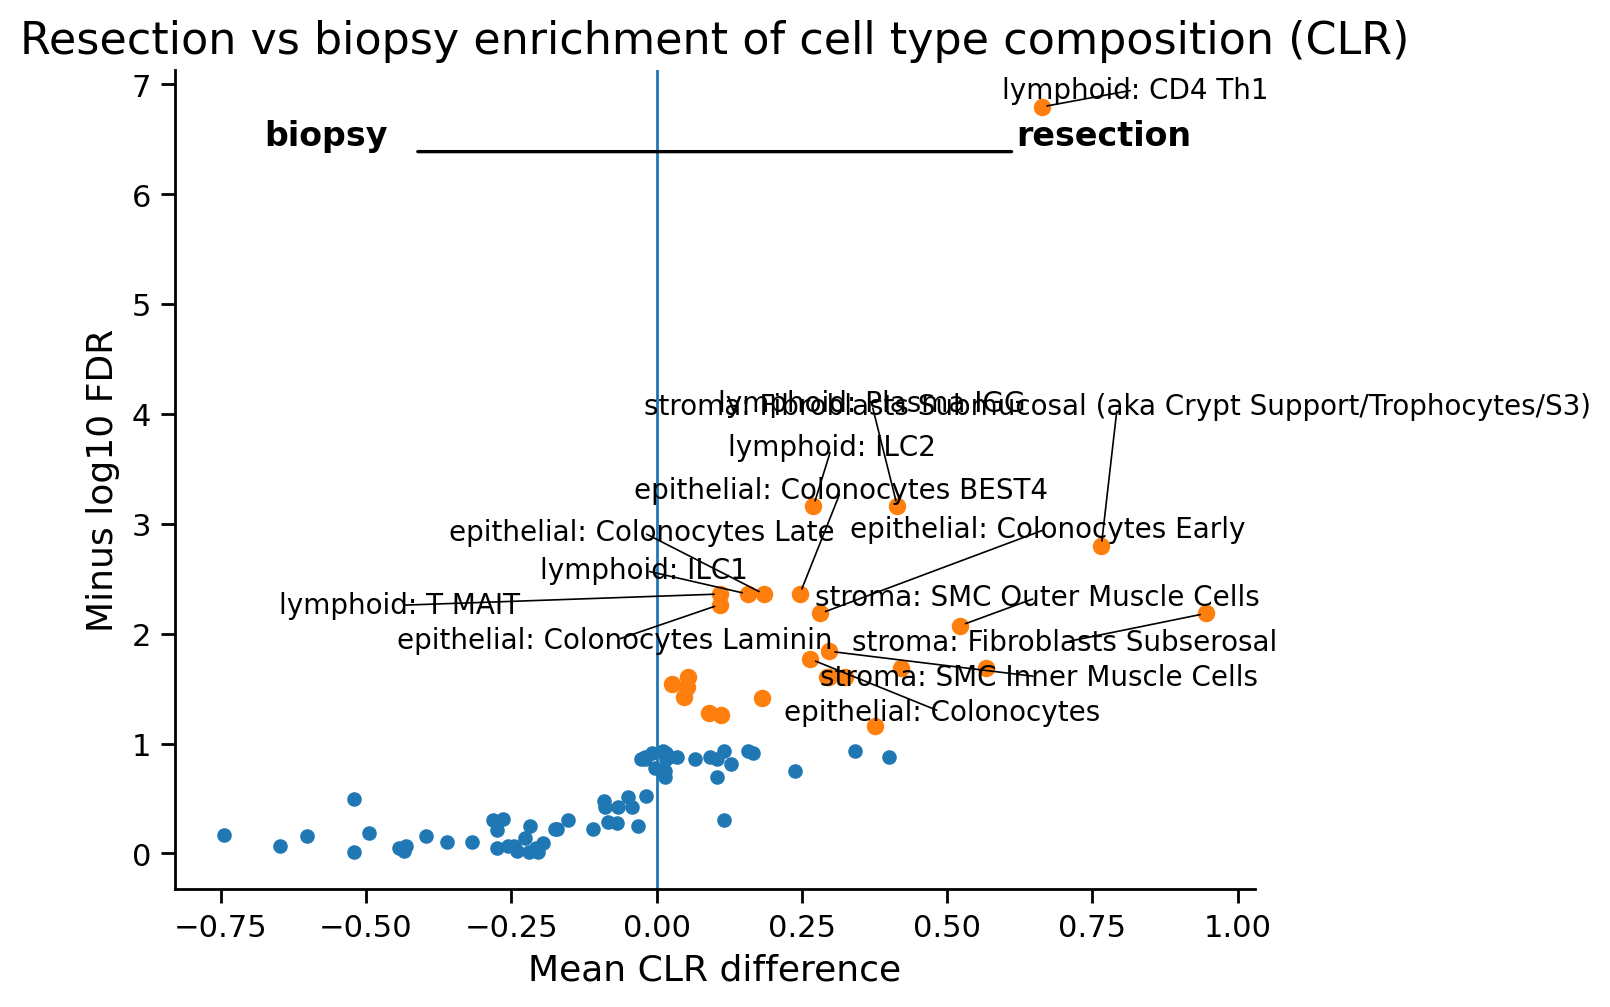

In [20]:
fig1 = plot_volcano(
    res_all,
    title="Resection vs biopsy enrichment of cell type composition (CLR)",
    q_cut=0.1,
    max_labels=14,
)
# fig1.savefig("clr_volcano.resection_vs_biopsy.png", bbox_inches="tight")



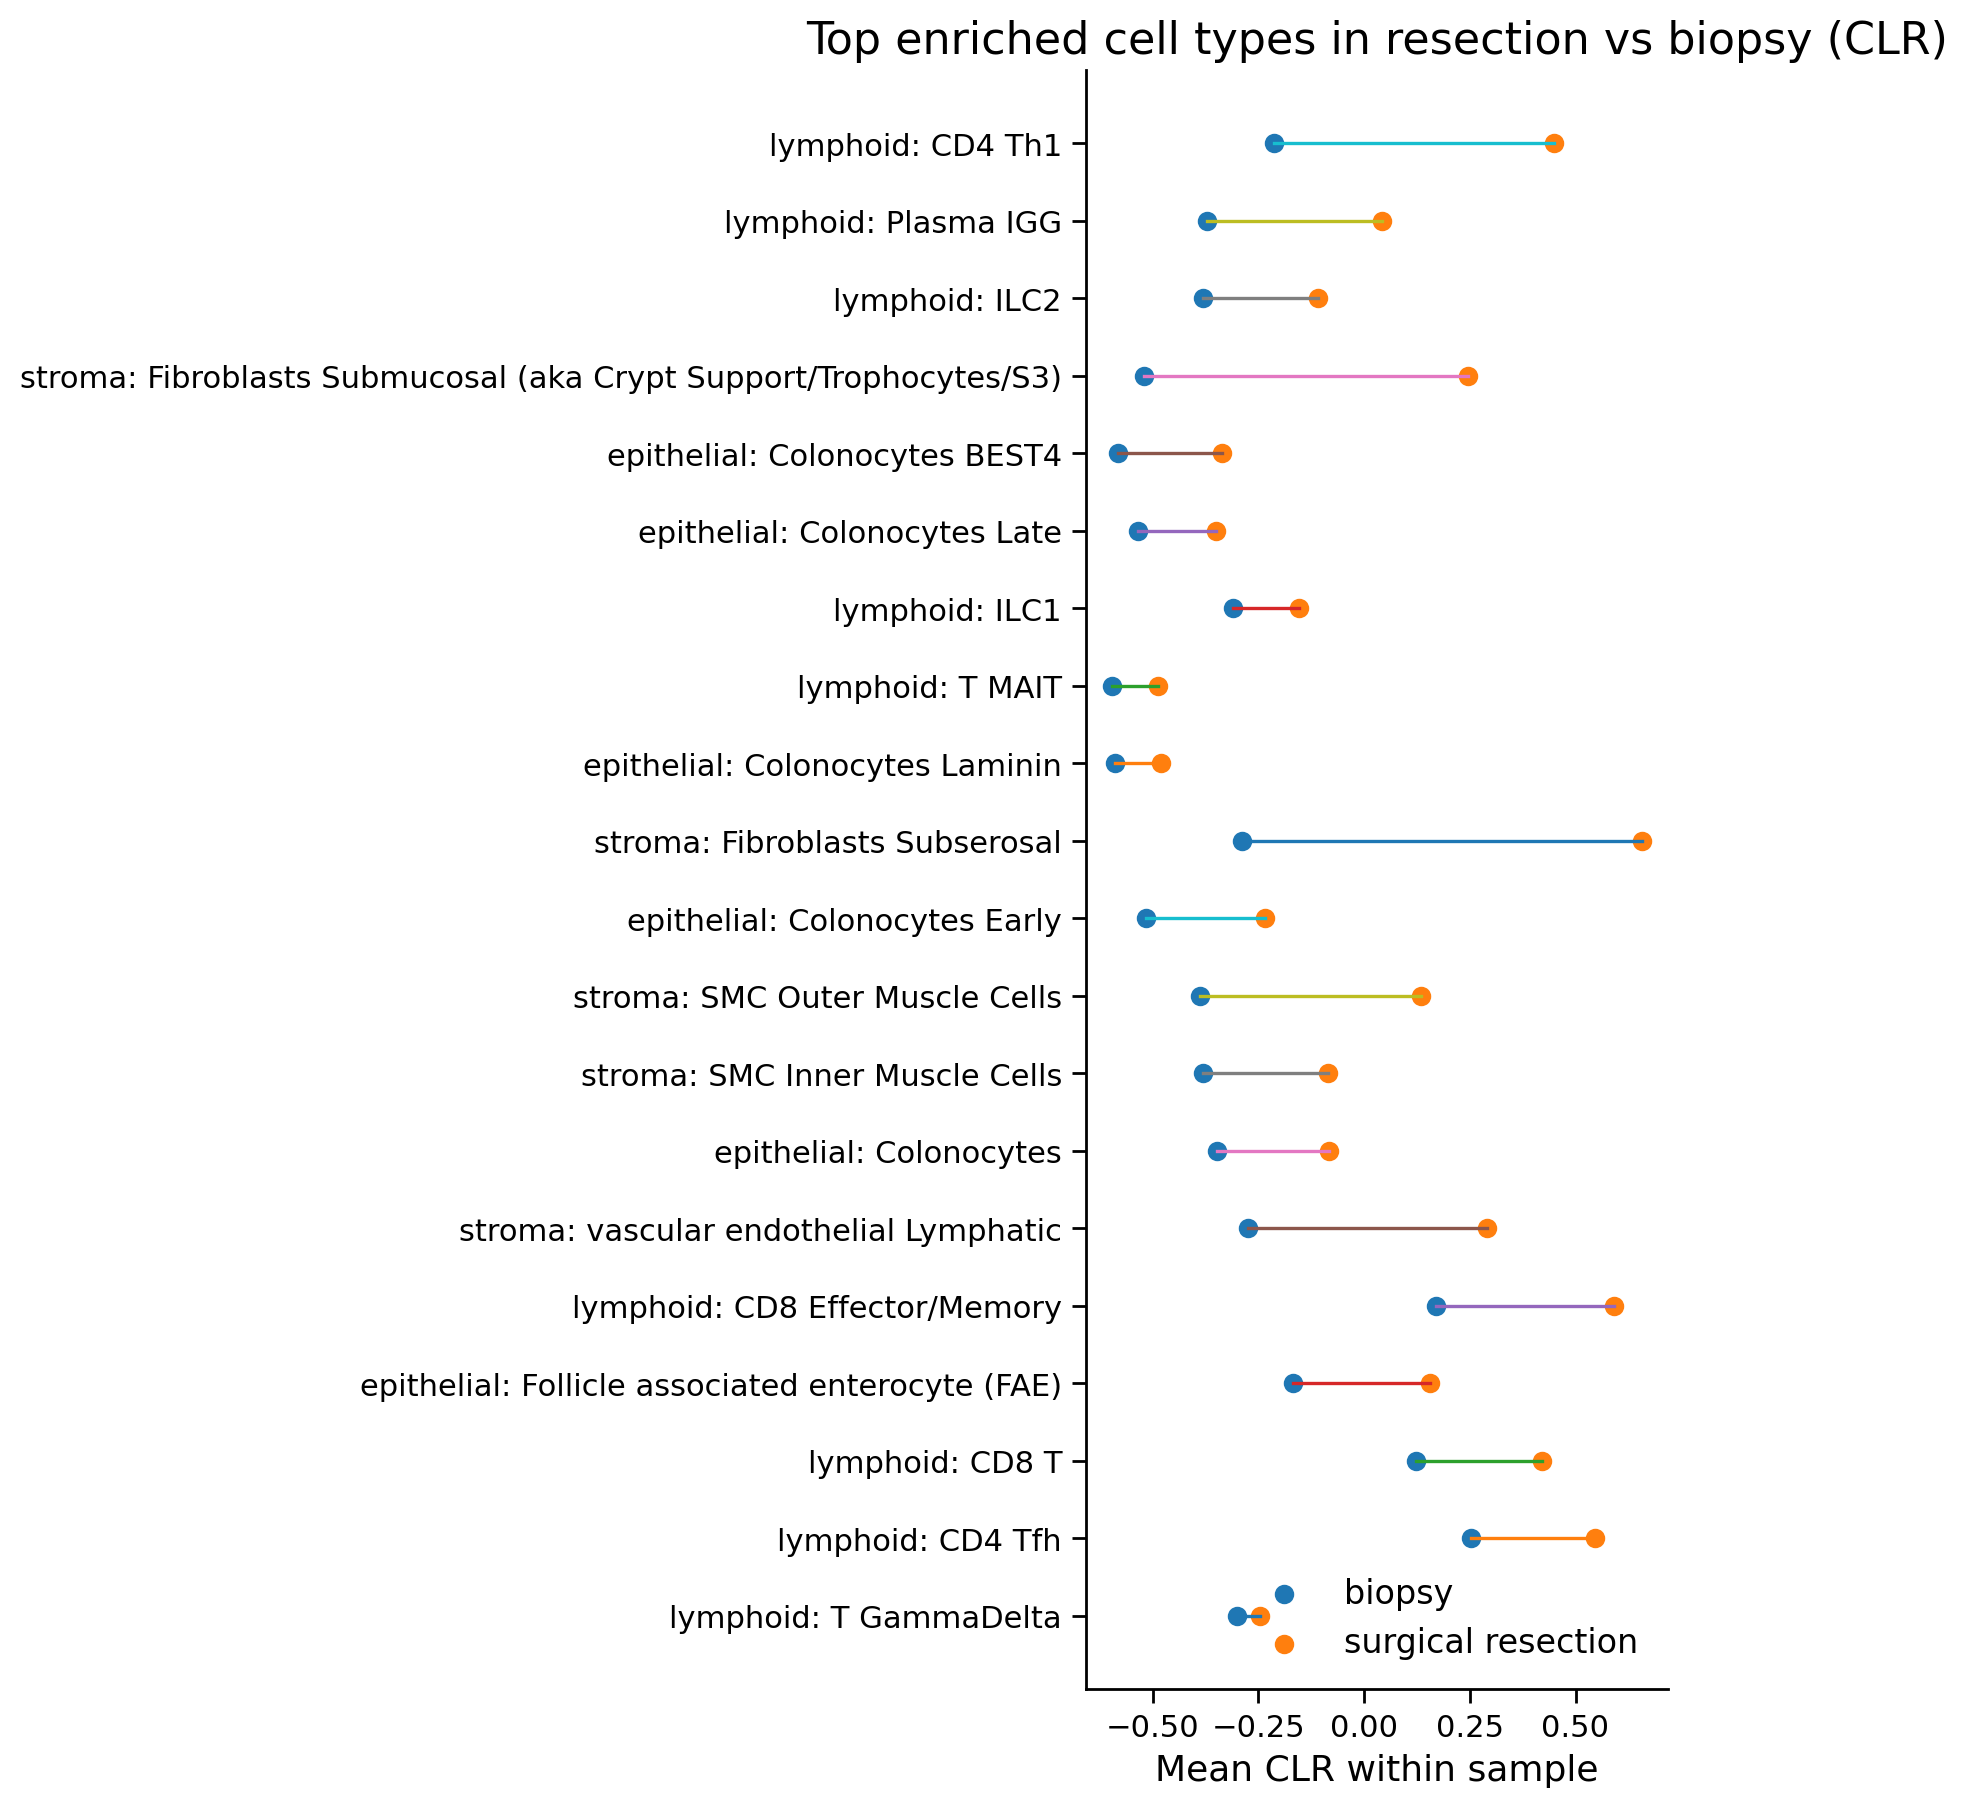

In [21]:
fig2 = plot_top_forest(
    clr_all,
    meta_all,
    res_all,
    method_col="sample_collection_method",
    title="Top enriched cell types in resection vs biopsy (CLR)",
    top_k=20,
)
# fig2.savefig("clr_top_forest.resection_vs_biopsy.png", bbox_inches="tight")




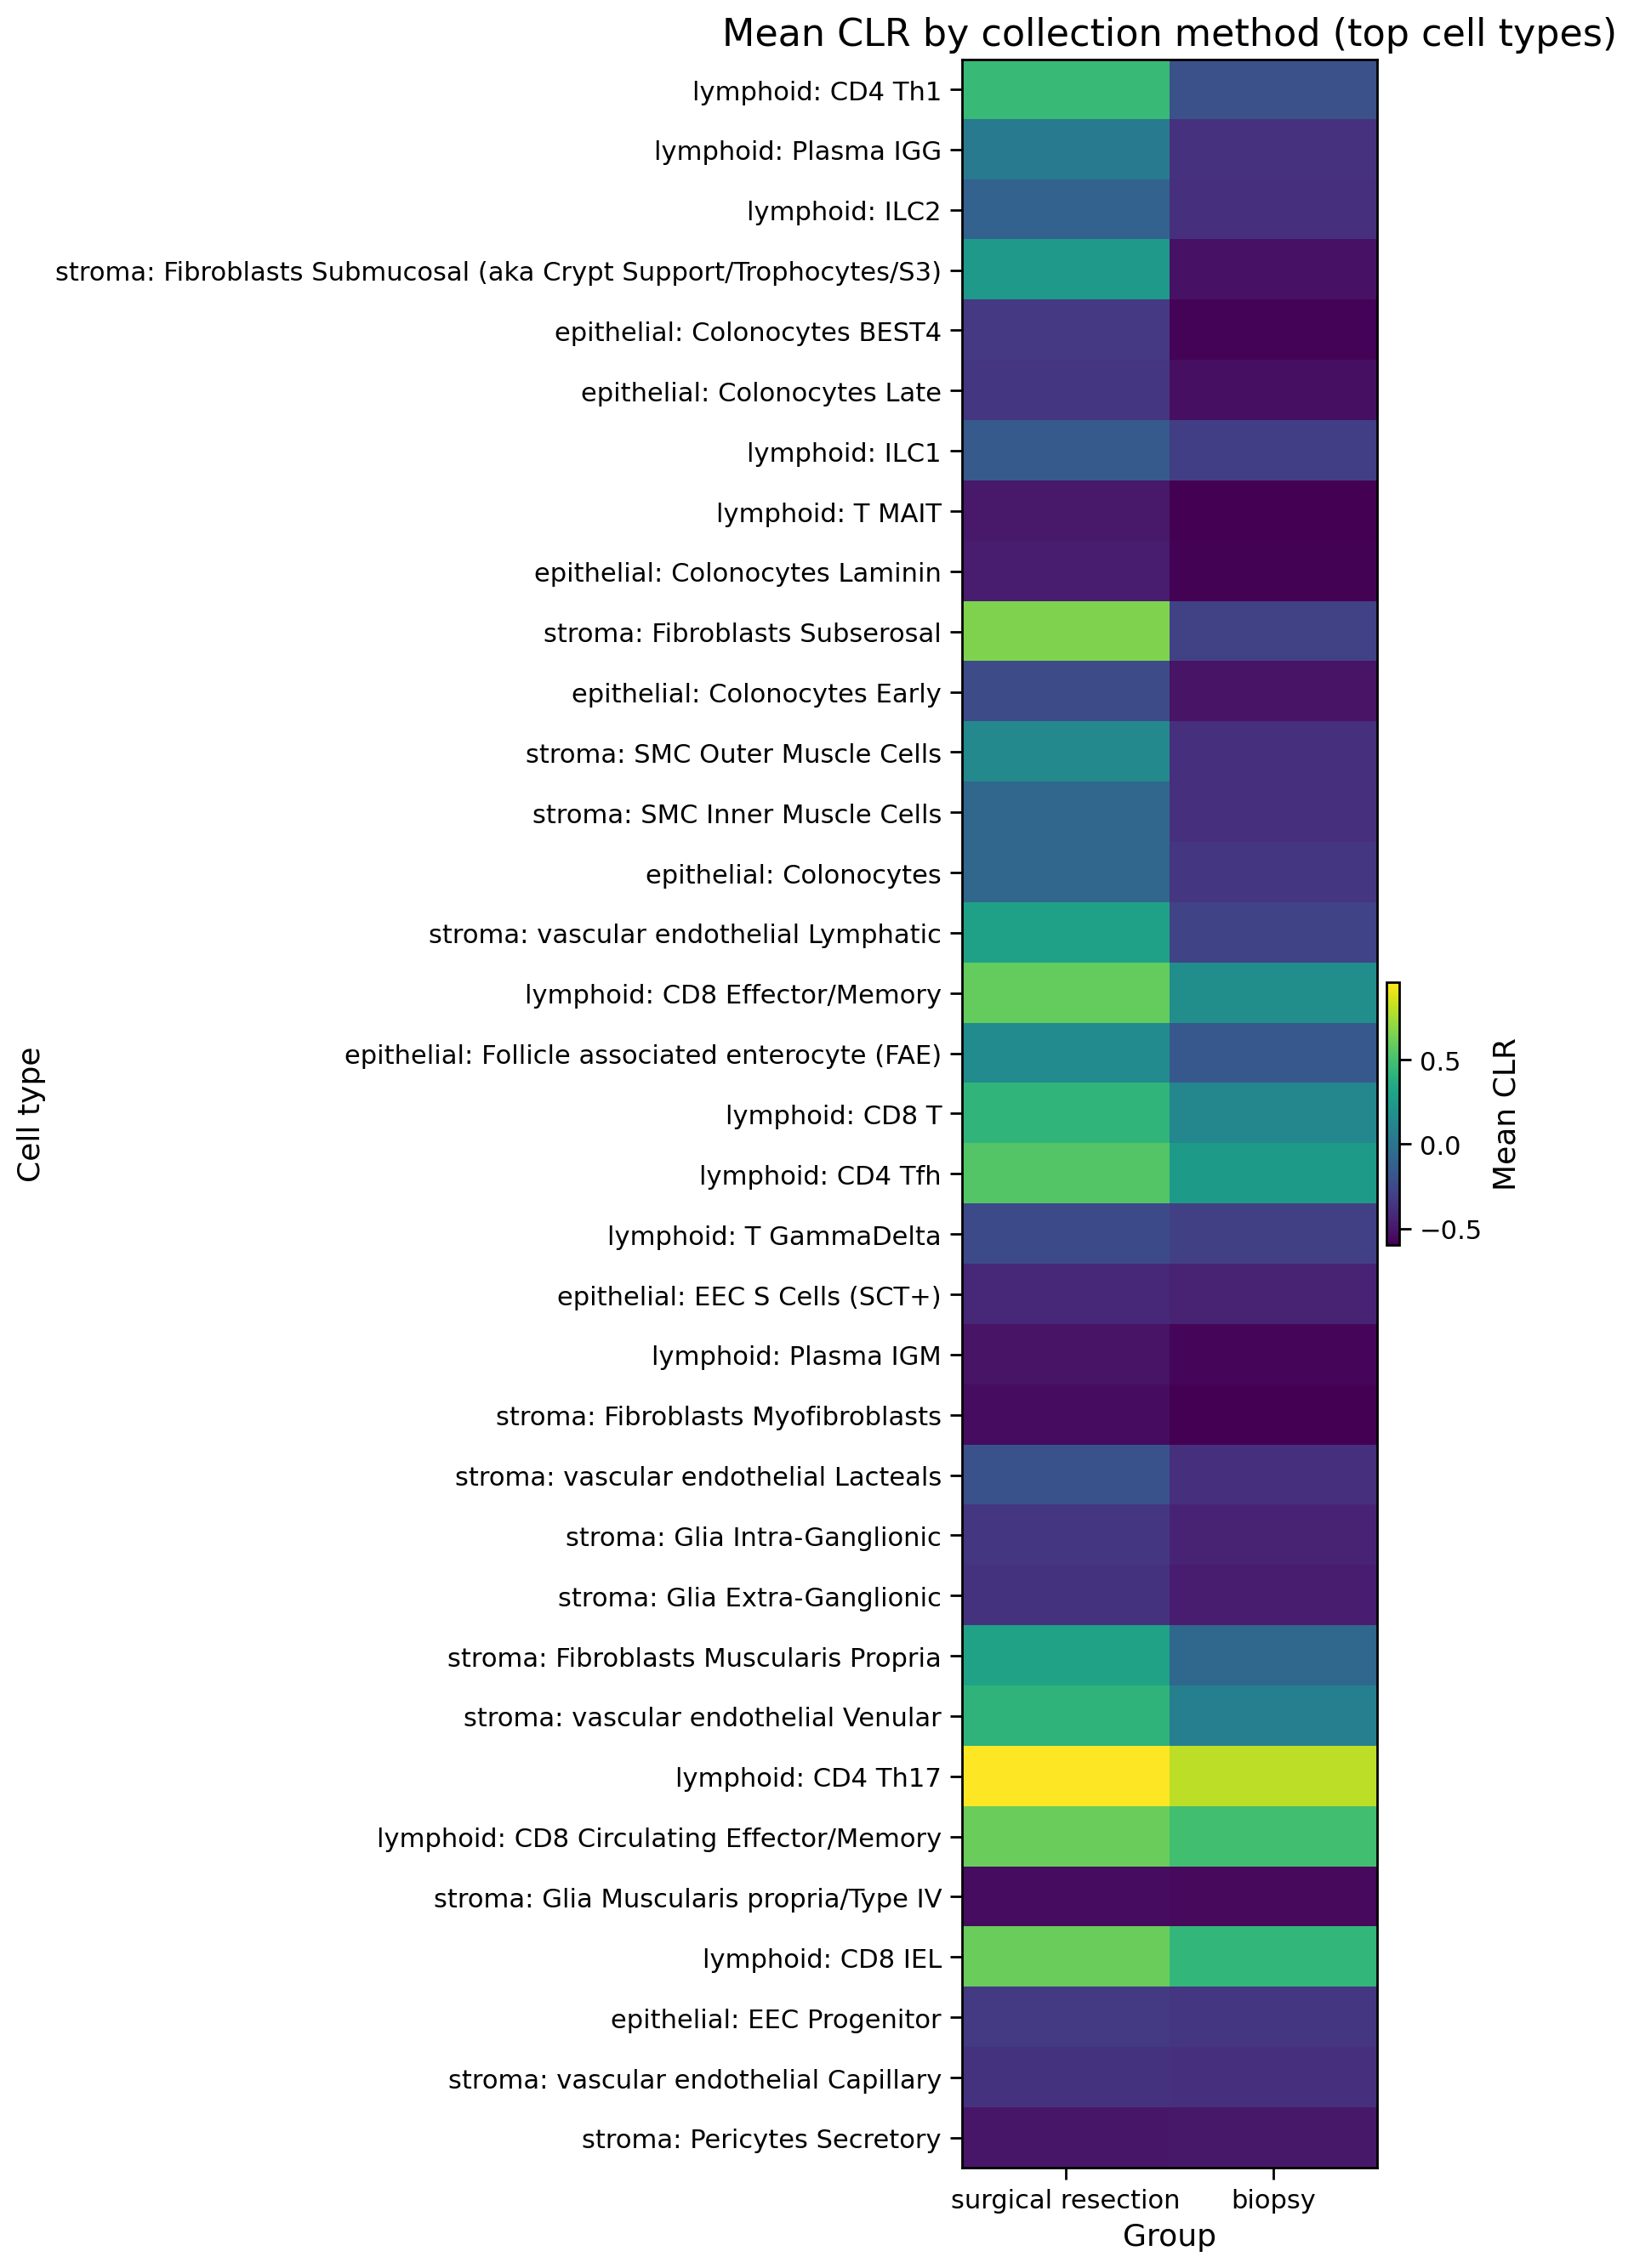

In [22]:

top_for_heatmap = (
    res_all[np.isfinite(res_all["qval"])]
    .sort_values(["qval", "effect_mean_clr"], ascending=[True, False])
    .head(35)["celltype"]
    .tolist()
)

fig3 = plot_method_heatmap(
    mean_clr_by_method[top_for_heatmap],
    title="Mean CLR by collection method (top cell types)",
)



# fig3.savefig("clr_heatmap.by_method.top_celltypes.png", bbox_inches="tight")
